In [75]:
import os, sys
from tqdm import tqdm
import torch
import numpy as np
from scipy import stats
from procrustes import rotational
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join(os.path.abspath(''), '..'))
from cmm.ffxml import ForceFieldXML
from cmm.topology import Topology
from cmm.units import BOHR2NM, BOHR2ANG, HARTREE2KCAL, AMU2ELECTRON_MASS, HARTREE2WAVENUMBER
from cmm.drivers import OptimizationDriver, HarmonicAnalysisDriver
from cmm.misc_utils import read_xyz, write_xyz, get_masses

import openmm.app as app
from ase.io import read

In [2]:
def rmsd(A: np.ndarray, B: np.ndarray):
    return np.sqrt(np.mean(np.sum((A - B)**2, axis=1)))

In [3]:
torch.set_default_dtype(torch.float64)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
ff_path = os.path.join(os.path.abspath(''), '../scripts/water_refit.xml')
ff = ForceFieldXML(ff_path, device=device)

In [4]:
water_cluster_pdb_path = os.path.join(os.path.abspath(''), '../tests/data/water_clusters/all_reference_clusters.pdb')
water_cluster_xyz_path = os.path.join(os.path.abspath(''), '../tests/data/water_clusters/all_reference_clusters.xyz')

In [101]:
water_cluster_pdb = app.PDBFile(water_cluster_pdb_path)
positions = [water_cluster_pdb.getPositions(True, frame=i)._value * 10.0 for i in range(water_cluster_pdb.getNumFrames())]

topologies = [Topology.fromMultiPDB(water_cluster_pdb_path, device, frame_index=i) for i in range(water_cluster_pdb.getNumFrames())]
systems = [ff.parametrize(topology, use_fd_morse=False, periodic=False, use_lr_dispersion=False, use_cutoff=False) for topology in topologies]

reference_coords, reference_labels = read_xyz(water_cluster_xyz_path)
reference_masses = [get_masses(reference_labels[i]) for i in range(len(reference_labels))]

In [102]:
coords = torch.from_numpy(positions[1] / BOHR2ANG).to(device).requires_grad_(False)
box = torch.tensor(np.eye(3) * 100.0, requires_grad=False, device=device)
energies = systems[1].getEnergy(coords, box)

for key in energies:
    print(f"{key}: {energies[key] * HARTREE2KCAL} kcal/mol")

bond: 0.6920237103165364 kcal/mol
angle: 0.023446173018395126 kcal/mol
torsion: 0.0 kcal/mol
bond_bond: -0.005611845671081472 kcal/mol
bond_angle: 0.03452899245356382 kcal/mol
angle_angle: 0.0 kcal/mol
torsion_bond: 0.0 kcal/mol
torsion_angle: 0.0 kcal/mol
torsion_angle_angle: 0.0 kcal/mol
perm_elec: -25.909409713076034 kcal/mol
pol: -3.7103559196676774 kcal/mol
ct_direct: -6.5340623624889105 kcal/mol
xpol: -0.6042721511840821 kcal/mol
pauli: 27.69132165343953 kcal/mol
disp: -6.185578241307645 kcal/mol
total: -14.507969704167406 kcal/mol


In [103]:
def optimize_all_reference_structures_and_compute_rmsds(systems, reference_coords):
    optimized_coords = []
    optimized_energies = []
    rmsds = []
    for i in range(len(systems)):
        opt_driver = OptimizationDriver(systems[i])
        coords = torch.from_numpy(reference_coords[i] / BOHR2ANG).to(device).requires_grad_(False)
        box = torch.tensor(np.eye(3) * 100.0, requires_grad=False, device=device)
        coords_opt, box_opt, result = opt_driver.run(coords, box)
        optimized_energies.append(result.fun * HARTREE2KCAL)
        if result.success == False:
            print(f"Warning: Optimization of structure {i} did not converge. Final energy was {optimized_energies[-1]} kcal/mol.")
        # Get RMSD and store new coordinates.
        # Align structures first in case they rotated during optimization.
        coords_opt = coords_opt.numpy() * BOHR2ANG
        result = rotational(coords_opt, reference_coords[i])
        optimized_coords.append(result.new_a)
        rmsd_i = rmsd(result.new_a, reference_coords[i])
        rmsds.append(rmsd_i)
        print(f"Structure {i}: Energy = {optimized_energies[-1]} kcal/mol, RMSD = {rmsd_i} Ang.")
    
    return optimized_coords, optimized_energies, rmsds

In [106]:
opt_coords, opt_energies, opt_rmsds = optimize_all_reference_structures_and_compute_rmsds(systems, reference_coords)

# Write out the optimized coords to a file
#write_xyz("reference_opt_cmm_without_fd_morse.xyz", reference_labels, opt_coords)

Structure 0: Energy = -4.862034548557489 kcal/mol, RMSD = 0.0012566566439348508 Ang.
Structure 1: Energy = -15.059076033162777 kcal/mol, RMSD = 0.0022891010851643643 Ang.
Structure 2: Energy = -27.08048272244855 kcal/mol, RMSD = 0.002755253437734033 Ang.
Structure 3: Energy = -35.70454246904853 kcal/mol, RMSD = 0.0027941515561678864 Ang.
Structure 4: Energy = -45.179913039128586 kcal/mol, RMSD = 0.0027989699886859544 Ang.
Structure 5: Energy = -44.92341816760889 kcal/mol, RMSD = 0.002879986155855557 Ang.
Structure 6: Energy = -45.13231521336021 kcal/mol, RMSD = 0.0028761065101131386 Ang.
Structure 7: Energy = -44.14792125309291 kcal/mol, RMSD = 0.0026636008253414114 Ang.
Structure 8: Energy = -56.889765071067664 kcal/mol, RMSD = 0.0030083034042325714 Ang.
Structure 9: Energy = -72.18026050374951 kcal/mol, RMSD = 0.003488338803989775 Ang.
Structure 10: Energy = -72.32943009247806 kcal/mol, RMSD = 0.0034341583146919297 Ang.
Structure 11: Energy = -81.70305854588914 kcal/mol, RMSD = 0.003

In [107]:
def compute_hbond_distance_freq_correlation_for_ref_clusters(systems, optimized_coord_file):
    all_dists = []
    all_freqs = []

    coords_opt, labels = read_xyz(optimized_coord_file)
    masses = [get_masses(labels[i]) for i in range(len(labels))]
    box = torch.tensor(np.eye(3) * 100.0, requires_grad=False, device=device)
    for geom_index in tqdm(range(len(coords_opt))):
        box = torch.tensor(np.eye(3) * 100.0, requires_grad=False, device=device)

        harmonic_driver = HarmonicAnalysisDriver(systems[geom_index])
        hessian = harmonic_driver.run(torch.from_numpy(coords_opt[geom_index] / BOHR2ANG).to(device).requires_grad_(False), box, masses[geom_index] * AMU2ELECTRON_MASS)
        eigvals, eigvecs = torch.linalg.eigh(hessian)
        freqs = torch.sqrt(eigvals) * HARTREE2WAVENUMBER

        # Find the atom which moves most for each hbond frequency
        minimum_hbond_frequency = 2500.0
        maximum_hbond_frequency = 3800.0
        mask = (freqs >= minimum_hbond_frequency) & (freqs <= maximum_hbond_frequency)
        hbond_indices = torch.nonzero(mask).squeeze()
        hbond_eigvces = eigvecs[:, hbond_indices]
        if hbond_eigvces.dim() == 1:
            hbond_eigvces.unsqueeze_(1)
        hbond_freqs = freqs[hbond_indices]
        if hbond_freqs.ndim == 1:
            hbond_freqs = hbond_freqs[np.newaxis, :]

        h_indices = torch.zeros(hbond_eigvces.size(-1), dtype=torch.long)
        for i in range(hbond_eigvces.size(-1)):
            mode = hbond_eigvces[:, i].reshape(-1, 3)
            h_index = torch.argmax(torch.linalg.norm(mode, dim=1))
            h_indices[i] = h_index

        # Get the distances between each hydrogen and the other oxygens in the system
        all_O_indices = []
        all_H_indices = []
        for i_geom in range(len(labels)):
            O_indices = []
            H_indices = []
            for i, label in enumerate(labels[i_geom]):
                if label == 'O':
                    O_indices.append(i)
                if label == 'H':
                    H_indices.append(i)
            all_O_indices.append(O_indices)
            all_H_indices.append(H_indices)

        all_O_indices = [torch.tensor(all_O_indices[i]) for i in range(len(all_O_indices))]
        all_H_indices = [torch.tensor(all_H_indices[i]) for i in range(len(all_H_indices))]

        for index in h_indices:
            if reference_labels[geom_index][index] != 'H':
                print("Warning: Found an h-bond frequency where the most mobile atom was not hydrogen.")

        H_atoms_hbond_only = coords_opt[geom_index][h_indices]
        O_atoms = coords_opt[geom_index][all_O_indices[geom_index]]
        if H_atoms_hbond_only.ndim == 1:
            H_atoms_hbond_only = H_atoms_hbond_only[np.newaxis, :]
            
        dist_vecs = H_atoms_hbond_only[:, np.newaxis, :] - O_atoms[np.newaxis, :, :]
        OH_hbond_dists = np.array([np.min(np.linalg.norm(dist_vecs[i], axis=1)) for i in range(dist_vecs.shape[0])])
        OH_hbond_dists_sorted = np.sort(OH_hbond_dists)[::-1]
        all_dists.append(OH_hbond_dists_sorted)
        all_freqs.append(hbond_freqs.numpy())
    return all_dists, all_freqs

In [109]:
all_freqs

array([3757.15445638, 3712.0749385 , 3726.39994268, 3727.74169622,
       3702.39348827, 3715.50882097, 3715.50882097, 3722.86658507,
       3706.61904225, 3714.21950402, 3716.72578389, 3721.72356256,
       3722.25469671, 3674.06794364, 3709.94692268, 3715.17911209,
       3716.61167758, 3725.95703524, 3735.37950711, 3791.48134403,
       3685.57440022, 3703.46785305, 3707.25948987, 3714.34589679,
       3720.77513187, 3727.37663956, 3693.86111188, 3703.03691507,
       3708.33077789, 3714.70727275, 3723.24078414, 3739.09709221,
       3712.88756467, 3718.87497204, 3718.87762255, 3723.74351477,
       3723.74625673, 3725.29269809, 3689.78251563, 3703.31062241,
       3706.70077032, 3711.2359762 , 3716.99130385, 3721.42990631,
       3734.12484653, 3796.67988142, 3695.21637336, 3697.5081894 ,
       3697.527838  , 3707.83430348, 3713.40103311, 3713.41716207,
       3713.86086544, 3719.05018609, 3793.05227929, 3793.19707559,
       3698.23574684, 3699.28111607, 3703.59606887, 3703.69791

In [108]:
opt_coords_path = water_cluster_xyz_path = os.path.join(os.path.abspath(''), 'reference_opt_cmm_without_fd_morse.xyz')
all_dists, all_freqs = compute_hbond_distance_freq_correlation_for_ref_clusters(systems, opt_coords_path)

100%|██████████| 25/25 [07:24<00:00, 17.80s/it]


ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 0 and the array at index 1 has size 3

In [99]:
def plot_badger_rule_correlation(r_hbond, freqs_hbond, title="Badger Rule Correlation"):
    r_eq_cmm = 0.9589289
    freq_ave_cmm = (3945.054377 + 3834.691479) / 2

    r_eq_wb97xv = 0.959274
    freq_ave_wb97xv = (3960.83 + 3859.85) / 2

    shifted_r_cmm = r_hbond - r_eq_cmm
    shifted_freqs_cmm = freqs_hbond - freq_ave_cmm

    slope, intercept, r_value, p_value, std_err = stats.linregress(shifted_r_cmm, shifted_freqs_cmm)
    
    line_x = np.linspace(shifted_r_cmm.min(), shifted_r_cmm.max(), 100)
    line_y = slope * line_x + intercept
    
    plt.figure(figsize=(10, 6))
    plt.scatter(shifted_r_cmm, shifted_freqs_cmm, alpha=0.7, color='blue', s=50, label='Data points')
    plt.plot(line_x, line_y, color='black', linewidth=2, linestyle="--",
             label=f'Linear fit: y = {slope:.2f}x + {intercept:.2f}')
    
    # Add statistics to the plot
    plt.text(0.05, 0.95, f'R² = {r_value**2:.3f}\nR = {r_value:.3f}\np-value = {p_value:.3e}', 
             transform=plt.gca().transAxes, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.xlabel('OH Bond Shift (Å)')
    plt.ylabel('Frequency Shift (cm^-1)')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("Linear Regression Results (scipy):")
    print(f"Slope: {slope:.4f}")
    print(f"Intercept: {intercept:.4f}")
    print(f"R-squared: {r_value**2:.4f}")
    print(f"Correlation coefficient: {r_value:.4f}")
    print(f"P-value: {p_value:.4e}")
    print(f"Standard error: {std_err:.4f}")

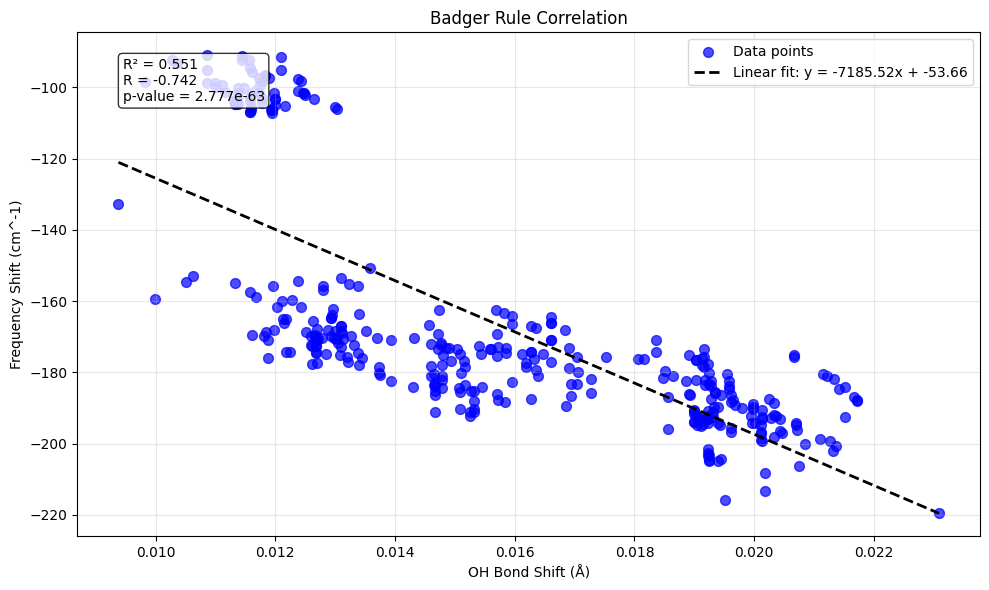

Linear Regression Results (scipy):
Slope: -7185.5217
Intercept: -53.6565
R-squared: 0.5506
Correlation coefficient: -0.7420
P-value: 2.7771e-63
Standard error: 345.5069


In [100]:
plot_badger_rule_correlation(all_dists, all_freqs)